<a href="https://colab.research.google.com/github/antonDinkov/AI_Agents_and_Workflows_for_Developers/blob/main/multi_agent_learning_plan_examen_softuni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Agent Learning Plan Assistant

## Scenario

This notebook implements a bounded four-agent learning-plan workflow with LangGraph and LangChain.

### Agents

1. **Requirements Analyst** – extracts the learning requirements.
2. **Learning Planner** – creates the day-by-day learning structure.
3. **Practice Designer** – creates practical exercises.
4. **Judge** – evaluates quality, requests at most a small number of targeted revisions, and merges accepted results.

Planner and Practice Designer run **in parallel** after the Analyst.

### Anti-loop / token-control rules

- Acceptance threshold: **75%**
- Maximum specialist revisions: **2 per agent**
- Maximum tool rounds inside one agent call: **2**
- The Judge does **not** penalize parallel agents for matching each other's exact day ordering.
- On retry, the unchanged specialist keeps its previous accepted score instead of being randomly re-scored.
- If the retry budget is exhausted, the workflow escalates to the mandatory Human-in-the-Loop review instead of looping forever.

These constraints make execution predictable and prevent unbounded token use.


In [1]:
!pip -q install -U langgraph langchain langchain-openai

## API key

Use an environment variable or Google Colab Secret named `OPENAI_API_KEY`.


In [2]:
''' import os

try:
    from google.colab import userdata
    if not os.getenv("OPENAI_API_KEY"):
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
except Exception:
    pass

assert os.getenv("OPENAI_API_KEY"), (
    "Set OPENAI_API_KEY as an environment variable or Colab Secret."
)
 '''

' import os\n\ntry:\n    from google.colab import userdata\n    if not os.getenv("OPENAI_API_KEY"):\n        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")\nexcept Exception:\n    pass\n\nassert os.getenv("OPENAI_API_KEY"), (\n    "Set OPENAI_API_KEY as an environment variable or Colab Secret."\n)\n '

## Imports and state

In [3]:
from typing import TypedDict, Literal
from uuid import uuid4

from pydantic import BaseModel, Field

from langchain_core.messages import (
    BaseMessage,
    SystemMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from google.colab import userdata

from IPython.display import display, Image

from unittest.mock import patch

In [4]:
class LearningRequirements(BaseModel):
    topic: str = Field(description="Topic to learn")
    days: int = Field(description="Number of learning days")
    hours_per_day: float = Field(description="Available hours per day")
    goal: str = Field(description="Learning goal")
    constraints: str = Field(description="Other constraints or 'None'")


class JudgeDecision(BaseModel):
    planner_score: int = Field(ge=0, le=100)
    practice_score: int = Field(ge=0, le=100)

    action: Literal[
        "approve",
        "revise_planner",
        "revise_practice",
    ]

    feedback: str = Field(
        description="One short correction sentence; empty when approved."
    )

    merged_result: str = Field(
        description="Merged result only when approved; empty otherwise."
    )


class SingleScore(BaseModel):
    score: int = Field(ge=0, le=100)
    feedback: str = Field(
        description="One short correction sentence; empty when score is satisfactory."
    )


class SharedContext(TypedDict, total=False):
    original_request: str
    requirements: dict
    analyst_tool_results: dict
    planner_feedback: str
    practice_feedback: str
    human_feedback: str
    feedback_history: list[str]


class WorkflowState(TypedDict, total=False):
    user_request: str
    shared_context: SharedContext

    planner_output: str
    practice_output: str

    planner_score: int
    practice_score: int

    planner_retries: int
    practice_retries: int
    judge_target: str

    merged_result: str
    final_output: str

    revision_count: int


## One shared tool pool

The tools are defined once and stored in one pool.

The Planner and Practice Designer both use this same pool. The Analyst also uses the same calculation functions to enrich the shared context before the parallel branches start.


In [5]:
@tool
def calculate_total_hours(days: int, hours_per_day: float) -> float:
    """Calculate total available learning hours."""
    return round(days * hours_per_day, 2)


@tool
def calculate_daily_sessions(hours_per_day: float) -> dict:
    """Convert daily study time into 45-minute sessions."""
    total_minutes = round(hours_per_day * 60)
    return {
        "full_45_min_sessions": total_minutes // 45,
        "remaining_minutes": total_minutes % 45,
    }


@tool
def allocate_study_time(
    hours_per_day: float,
    practice_ratio: float = 0.4,
) -> dict:
    """Split daily time between learning and practice."""
    total_minutes = round(hours_per_day * 60)
    practice_minutes = round(total_minutes * practice_ratio)

    return {
        "learning_minutes": total_minutes - practice_minutes,
        "practice_minutes": practice_minutes,
    }


tools = [
    calculate_total_hours,
    calculate_daily_sessions,
    allocate_study_time,
]

TOOL_POOL = {
    tool.name: tool
    for tool in tools
}


## Models

Normal agents use `gpt-5.6-luna`.

The Judge uses `gpt-5.6-terra4`.


In [6]:
NORMAL_MODEL_NAME = "gpt-5.6-luna"
JUDGE_MODEL_NAME = "gpt-5.6-terra"
api_key_openai = userdata.get("OPEN_AI_API_KEY")

normal_llm = ChatOpenAI(
    model=NORMAL_MODEL_NAME,
    api_key=api_key_openai,
    reasoning_effort="none",
    temperature=0,
    max_tokens=10000,
)

judge_llm = ChatOpenAI(
    model=JUDGE_MODEL_NAME,
    api_key=api_key_openai,
    temperature=0,
    max_tokens=5000,
)

analyst_llm = normal_llm.with_structured_output(LearningRequirements)
planner_llm = normal_llm.bind_tools(tools)
practice_llm = normal_llm.bind_tools(tools)

judge_structured_llm = judge_llm.with_structured_output(JudgeDecision)
judge_single_score_llm = judge_llm.with_structured_output(SingleScore)

ACCEPTANCE_SCORE = 75
MAX_AGENT_REVISIONS = 2
MAX_TOOL_ROUNDS = 2


## Prompts

In [7]:
ANALYST_PROMPT = """
You are the Requirements Analyst.

Extract the user's learning requirements.
Do not create a learning plan.
Return only the requested structured fields.
""".strip()


PLANNER_PROMPT = """
You are the Learning Planner.

Create only the day-by-day learning structure.
Respect the shared requirements and available time.

You have access to tools.
Use them only when a calculation is actually necessary.

Do not create detailed practical exercises.
That is the Practice Designer's responsibility.

If PLANNER FEEDBACK is present, revise only that issue.

Be concise. Return one line per day.
""".strip()


PRACTICE_PROMPT = """
You are the Practice Designer.

Create the practical part of the learning plan.
Provide one short hands-on task for every learning day.

Respect the shared requirements and available time.

You have access to the same tool pool as the Planner.
Use tools only when a calculation is actually necessary.

Do not attempt to guess the Planner's exact day ordering because both agents
work in parallel. Base the exercises on the shared requirements.

If PRACTICE FEEDBACK is present, revise only that issue.

Be concise. Return one line per day.
""".strip()


JUDGE_PROMPT = """
You are the Judge.

Evaluate Planner and Practice Designer independently against the SAME shared
requirements.

Important:
- Planner and Practice run in parallel.
- Do NOT require the Practice output to match the Planner's exact day ordering.
- Do NOT invent missing requirements.
- Do NOT reduce the score of an unchanged accepted output during a targeted retry.

Score each output from 0 to 100.

A score of 75 or above is satisfactory.

Planner criteria:
- respects topic, days, time and goal;
- provides a coherent learning structure;
- workload is realistic.

Practice criteria:
- respects topic, days, time and goal;
- contains concrete hands-on work;
- workload is realistic.

Only treat the two outputs as conflicting if they contradict an explicit user
requirement. Exact same-day topic alignment is NOT required.

If planner_score < 75:
    action = revise_planner
Else if practice_score < 75:
    action = revise_practice
Else:
    action = approve

For revision:
- feedback = exactly one short concrete sentence;
- merged_result = empty.

For approval:
- feedback = empty;
- merge both outputs into one concise learning plan;
- do not add facts or topics that do not appear in the requirements or specialist outputs.
""".strip()


SINGLE_RECHECK_PROMPT = """
You are the Judge performing a TARGETED re-check.

Evaluate only the revised specialist output against the explicit requirements.

Do not compare it to the other specialist's exact ordering.
Do not invent new requirements.
Do not introduce new criticism unrelated to the previous feedback.

Return:
- score from 0 to 100;
- empty feedback if score >= 75;
- otherwise one short concrete correction sentence.
""".strip()


## Internal tool loop

This helper lets an agent call tools repeatedly until the model stops requesting them.

Because the loop is inside the agent function, the graph remains visually simple.


In [8]:
def run_agent_with_tools(
    llm_with_tools,
    system_prompt: str,
    task: str,
):
    messages: list[BaseMessage] = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=task),
    ]

    for _ in range(MAX_TOOL_ROUNDS):
        response = llm_with_tools.invoke(messages)
        messages.append(response)

        tool_calls = getattr(response, "tool_calls", None)

        if not tool_calls:
            return response.content

        for tool_call in tool_calls:
            tool_name = tool_call["name"]

            if tool_name not in TOOL_POOL:
                raise ValueError(f"Unknown tool: {tool_name}")

            result = TOOL_POOL[tool_name].invoke(
                tool_call["args"]
            )

            messages.append(
                ToolMessage(
                    content=str(result),
                    tool_call_id=tool_call["id"],
                    name=tool_name,
                )
            )

    # Hard stop for tool use: produce a short final answer without more tools.
    final_messages = messages + [
        HumanMessage(
            content=(
                "Tool-call budget is exhausted. "
                "Use the tool results already available and return the final concise answer now. "
                "Do not request more tools."
            )
        )
    ]

    final_response = normal_llm.invoke(final_messages)
    return final_response.content


## Four agent nodes

In [9]:
def analyst_agent(state: WorkflowState):
    print("\n[1. ANALYST]")

    requirements = analyst_llm.invoke([
        SystemMessage(content=ANALYST_PROMPT),
        HumanMessage(content=state["user_request"]),
    ])

    req = requirements.model_dump()

    analyst_tool_results = {
        "total_hours": calculate_total_hours.invoke({
            "days": req["days"],
            "hours_per_day": req["hours_per_day"],
        }),
        "daily_sessions": calculate_daily_sessions.invoke({
            "hours_per_day": req["hours_per_day"],
        }),
        "time_allocation": allocate_study_time.invoke({
            "hours_per_day": req["hours_per_day"],
            "practice_ratio": 0.4,
        }),
    }

    context: SharedContext = {
        "original_request": state["user_request"],
        "requirements": req,
        "analyst_tool_results": analyst_tool_results,
        "planner_feedback": "",
        "practice_feedback": "",
        "human_feedback": "",
        "feedback_history": [],
    }

    print("[Requirements]", req)
    print("[Shared tool results]", analyst_tool_results)

    return {
        "shared_context": context,
        "planner_retries": 0,
        "practice_retries": 0,
        "judge_target": "both",
        "revision_count": 0,
    }


def planner_agent(state: WorkflowState):
    print("\n[2. PLANNER]")

    context = state["shared_context"]

    task = f"""
SHARED CONTEXT:
{context}

PLANNER FEEDBACK:
{context.get("planner_feedback") or "None"}

Create or revise the planner output.
"""

    result = run_agent_with_tools(
        planner_llm,
        PLANNER_PROMPT,
        task,
    )

    print("[Planner result ready]")

    return {
    "planner_output": result,
    }


def practice_agent(state: WorkflowState):
    print("\n[3. PRACTICE DESIGNER]")

    context = state["shared_context"]

    task = f"""
SHARED CONTEXT:
{context}

PRACTICE FEEDBACK:
{context.get("practice_feedback") or "None"}

Create or revise the practice output.
"""

    result = run_agent_with_tools(
        practice_llm,
        PRACTICE_PROMPT,
        task,
    )

    print("[Practice result ready]")

    return {
    "practice_output": result,
    }


def _merge_with_judge(state: WorkflowState) -> str:
    context = state["shared_context"]

    merge = judge_structured_llm.invoke([
        SystemMessage(content=JUDGE_PROMPT),
        HumanMessage(
            content=f"""
Both specialist outputs have already reached the acceptance threshold.

REQUIREMENTS:
{context["requirements"]}

PLANNER OUTPUT:
{state["planner_output"]}

PRACTICE OUTPUT:
{state["practice_output"]}

Return action=approve and merge them concisely.
"""
        ),
    ])

    return merge.merged_result


def judge_agent(
    state: WorkflowState,
) -> Command[
    Literal[
        "planner",
        "practice",
        "human_review",
    ]
]:
    print("\n[4. JUDGE]")

    context = state["shared_context"]
    target = state.get("judge_target", "both")

    # INITIAL evaluation: score both once.
    if target == "both":
        decision = judge_structured_llm.invoke([
            SystemMessage(content=JUDGE_PROMPT),
            HumanMessage(
                content=f"""
REQUIREMENTS:
{context["requirements"]}

ANALYST CALCULATIONS:
{context["analyst_tool_results"]}

PLANNER OUTPUT:
{state["planner_output"]}

PRACTICE OUTPUT:
{state["practice_output"]}
"""
            ),
        ])

        planner_score = decision.planner_score
        practice_score = decision.practice_score

        print(
            f"[Scores] Planner={planner_score}% | "
            f"Practice={practice_score}%"
        )

        if (
            planner_score >= ACCEPTANCE_SCORE
            and practice_score >= ACCEPTANCE_SCORE
        ):
            print("[Judge] APPROVED")

            return Command(
                update={
                    "planner_score": planner_score,
                    "practice_score": practice_score,
                    "merged_result": decision.merged_result,
                    "judge_target": "both",
                },
                goto="human_review",
            )

        updated_context = dict(context)

        if planner_score < ACCEPTANCE_SCORE:
            feedback = decision.feedback or "Improve the planner to satisfy the explicit requirements."
            updated_context["planner_feedback"] = feedback
            print("[Judge -> Planner]", feedback)

            return Command(
                update={
                    "planner_score": planner_score,
                    "practice_score": practice_score,
                    "planner_retries": 1,
                    "judge_target": "planner",
                    "shared_context": updated_context,
                    "revision_count": state.get("revision_count", 0) + 1,
                },
                goto="planner",
            )

        feedback = decision.feedback or "Improve the practice output to satisfy the explicit requirements."
        updated_context["practice_feedback"] = feedback
        print("[Judge -> Practice]", feedback)

        return Command(
            update={
                "planner_score": planner_score,
                "practice_score": practice_score,
                "practice_retries": 1,
                "judge_target": "practice",
                "shared_context": updated_context,
                "revision_count": state.get("revision_count", 0) + 1,
            },
            goto="practice",
        )

    # TARGETED re-check: only the changed branch is re-scored.
    if target == "planner":
        recheck = judge_single_score_llm.invoke([
            SystemMessage(content=SINGLE_RECHECK_PROMPT),
            HumanMessage(
                content=f"""
REQUIREMENTS:
{context["requirements"]}

PREVIOUS JUDGE FEEDBACK:
{context.get("planner_feedback", "")}

REVISED PLANNER OUTPUT:
{state["planner_output"]}
"""
            ),
        ])

        planner_score = recheck.score
        practice_score = state.get("practice_score", ACCEPTANCE_SCORE)

        print(
            f"[Scores] Planner={planner_score}% | "
            f"Practice={practice_score}% (frozen)"
        )

        if planner_score >= ACCEPTANCE_SCORE:
            # If the other branch was already good, merge now.
            if practice_score >= ACCEPTANCE_SCORE:
                merged = _merge_with_judge(state)
                return Command(
                    update={
                        "planner_score": planner_score,
                        "merged_result": merged,
                        "judge_target": "both",
                    },
                    goto="human_review",
                )

            updated_context = dict(context)
            updated_context["practice_feedback"] = (
                updated_context.get("practice_feedback")
                or "Improve the practice output to satisfy the explicit requirements."
            )

            return Command(
                update={
                    "planner_score": planner_score,
                    "judge_target": "practice",
                    "shared_context": updated_context,
                },
                goto="practice",
            )

        retries = state.get("planner_retries", 0)

        if retries >= MAX_AGENT_REVISIONS:
            print("[Judge] Planner retry budget exhausted -> Human Review")
            return Command(
                update={
                    "planner_score": planner_score,
                    "merged_result": (
                        "REVIEW REQUIRED: Planner remained below the 75% threshold "
                        f"after {MAX_AGENT_REVISIONS} revisions.\n\n"
                        f"PLANNER:\n{state['planner_output']}\n\n"
                        f"PRACTICE:\n{state['practice_output']}"
                    ),
                },
                goto="human_review",
            )

        updated_context = dict(context)
        updated_context["planner_feedback"] = recheck.feedback
        print("[Judge -> Planner]", recheck.feedback)

        return Command(
            update={
                "planner_score": planner_score,
                "planner_retries": retries + 1,
                "shared_context": updated_context,
                "revision_count": state.get("revision_count", 0) + 1,
            },
            goto="planner",
        )

    # target == practice
    recheck = judge_single_score_llm.invoke([
        SystemMessage(content=SINGLE_RECHECK_PROMPT),
        HumanMessage(
            content=f"""
REQUIREMENTS:
{context["requirements"]}

PREVIOUS JUDGE FEEDBACK:
{context.get("practice_feedback", "")}

REVISED PRACTICE OUTPUT:
{state["practice_output"]}
"""
        ),
    ])

    practice_score = recheck.score
    planner_score = state.get("planner_score", ACCEPTANCE_SCORE)

    print(
        f"[Scores] Planner={planner_score}% (frozen) | "
        f"Practice={practice_score}%"
    )

    if practice_score >= ACCEPTANCE_SCORE:
        if planner_score >= ACCEPTANCE_SCORE:
            merged = _merge_with_judge(state)
            return Command(
                update={
                    "practice_score": practice_score,
                    "merged_result": merged,
                    "judge_target": "both",
                },
                goto="human_review",
            )

        updated_context = dict(context)
        updated_context["planner_feedback"] = (
            updated_context.get("planner_feedback")
            or "Improve the planner to satisfy the explicit requirements."
        )

        return Command(
            update={
                "practice_score": practice_score,
                "judge_target": "planner",
                "shared_context": updated_context,
            },
            goto="planner",
        )

    retries = state.get("practice_retries", 0)

    if retries >= MAX_AGENT_REVISIONS:
        print("[Judge] Practice retry budget exhausted -> Human Review")
        return Command(
            update={
                "practice_score": practice_score,
                "merged_result": (
                    "REVIEW REQUIRED: Practice remained below the 75% threshold "
                    f"after {MAX_AGENT_REVISIONS} revisions.\n\n"
                    f"PLANNER:\n{state['planner_output']}\n\n"
                    f"PRACTICE:\n{state['practice_output']}"
                ),
            },
            goto="human_review",
        )

    updated_context = dict(context)
    updated_context["practice_feedback"] = recheck.feedback
    print("[Judge -> Practice]", recheck.feedback)

    return Command(
        update={
            "practice_score": practice_score,
            "practice_retries": retries + 1,
            "shared_context": updated_context,
            "revision_count": state.get("revision_count", 0) + 1,
        },
        goto="practice",
    )


## Human-in-the-Loop and finalization

The Judge must approve both specialist outputs first.

Then the workflow pauses for human approval before returning the final result.


In [10]:
def human_review(
    state: WorkflowState,
) -> Command[Literal["judge", "finalize"]]:

    print("\n[HUMAN REVIEW]")
    print(state["merged_result"])

    feedback = interrupt({
        "question": (
            "Type 'approve' to finalize, "
            "or enter short feedback for another revision."
        ),
        "draft": state["merged_result"],
    })

    feedback_text = str(feedback).strip()

    if feedback_text.lower() == "approve":
        return Command(
            goto="finalize"
        )

    context = dict(state["shared_context"])

    history = list(
        context.get("feedback_history", [])
    )
    history.append(feedback_text)

    context["feedback_history"] = history
    context["human_feedback"] = feedback_text

    return Command(
        update={
            "shared_context": context,
        },
        goto="judge",
    )


def finalize(state: WorkflowState):
    return {
        "final_output": state["merged_result"]
    }


## Clean LangGraph architecture

Only the real workflow steps appear in the graph.

Planner and Practice Designer are parallel branches. Their results converge in Judge.

Judge can return only the relevant specialist for revision.


In [11]:
def build_graph():
    builder = StateGraph(WorkflowState)

    builder.add_node("analyst", analyst_agent)
    builder.add_node("planner", planner_agent)
    builder.add_node("practice", practice_agent)
    builder.add_node("judge", judge_agent)

    builder.add_node("human_review", human_review)
    builder.add_node("finalize", finalize)

    builder.add_edge(START, "analyst")

    # True parallel fan-out.
    builder.add_edge("analyst", "planner")
    builder.add_edge("analyst", "practice")

    # Initial fan-in barrier: Judge waits for both parallel branches.
    builder.add_edge(
        ["planner", "practice"],
        "judge",
    )

    builder.add_edge("finalize", END)

    memory = MemorySaver()

    return builder.compile(
        checkpointer=memory
    )


def execute_workflow(user_request: str):
    graph = build_graph()

    config = {
        "configurable": {
            "thread_id": str(uuid4())
        },
        # Final safety net against accidental graph cycles.
        "recursion_limit": 20,
    }

    result = graph.invoke(
        {
            "user_request": user_request
        },
        config=config,
    )

    while "__interrupt__" in result:
        payload = result["__interrupt__"][0].value

        print("\nSYSTEM:", payload["question"])

        human_feedback = input("Human feedback: ")
        print("Human feedback:", human_feedback)

        result = graph.invoke(
            Command(resume=human_feedback),
            config=config,
        )

    print("\nFINAL OUTPUT:\n")
    print(result["final_output"])

    return result["final_output"]


## Visualization

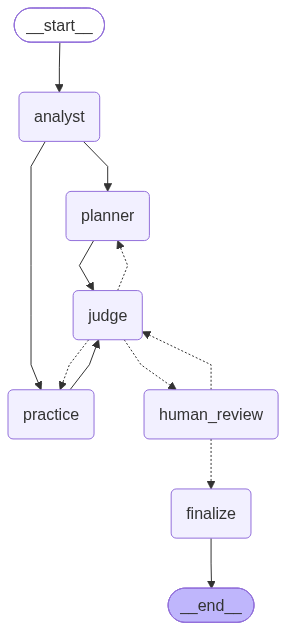

In [12]:
graph = build_graph()

try:
    display(
        Image(
            data=graph.get_graph().draw_mermaid_png(),
            format="png",
        )
    )
except Exception:
    print(graph.get_graph().draw_mermaid())


## Expected architecture

```text
                START
                  |
                  v
               ANALYST
               /     \
              v       v
         PLANNER     PRACTICE
              \       /
               \     /
                JUDGE
              /   |   \
       retry P retry R  >=75%
          |       |       |
          v       v       v
       PLANNER PRACTICE HUMAN REVIEW
          |       |       |
          +---JUDGE       approve
                          |
                          v
                       FINALIZE
                          |
                          v
                         END
```

### Bounded execution

- Max 2 tool rounds per specialist call.
- Max 2 Judge-requested revisions per specialist.
- Unchanged branch scores are frozen during a targeted retry.
- If a branch is still below 75% after its retry budget, the workflow goes to Human Review instead of looping.
- `recursion_limit=20` is an additional graph-level safety net.


## Quick smoke test

Run this first. It uses only one request, so you can verify the workflow before executing all five required test cases.


In [13]:
quick_request = (
    "Learn Python basics in 5 days. I can study 1 hour per day. "
    "My goal is to understand variables, conditions, loops and functions."
)

with patch("builtins.input", side_effect=["approve"]):
    execute_workflow(quick_request)



[1. ANALYST]
[Requirements] {'topic': 'Python basics', 'days': 5, 'hours_per_day': 1.0, 'goal': 'Understand variables, conditions, loops, and functions', 'constraints': 'None'}
[Shared tool results] {'total_hours': 5.0, 'daily_sessions': {'full_45_min_sessions': 1, 'remaining_minutes': 15}, 'time_allocation': {'learning_minutes': 36, 'practice_minutes': 24}}

[2. PLANNER]

[3. PRACTICE DESIGNER]
[Planner result ready]
[Practice result ready]

[4. JUDGE]
[Scores] Planner=96% | Practice=97%
[Judge] APPROVED

[HUMAN REVIEW]
5-day Python basics plan (1 hour per day):
Day 1: Learn Python syntax fundamentals, values, data types, assignment, and basic input/output. Practice by storing your name, age, and favorite color in variables and printing a sentence.
Day 2: Learn Boolean values, comparison and logical operators, and if/elif/else conditions. Practice a program that classifies an entered number as positive, negative, or zero.
Day 3: Learn for and while loops, ranges, iteration, and loop 

## Five test cases

Test 4 demonstrates human feedback after Judge approval.


In [14]:
from unittest.mock import patch

test_cases = [
    (
        "Learn Python basics in 14 days. I can study 1 hour per day. "
        "My goal is to understand variables, conditions, loops, functions and collections."
    ),
    (
        "Prepare SQL for a junior data analyst interview in 7 days. "
        "I can study 2 hours per day. My goal is to practice SELECT, JOIN, GROUP BY and subqueries."
    ),
    (
        "Learn Git fundamentals in 5 days. I can study 45 minutes per day. "
        "My goal is to use commits, branches, merge, pull and push confidently."
    ),
    (
        "Learn pandas for data analysis in 10 days. I can study 1.5 hours per day. "
        "My goal is to load, clean, filter, group and summarize tabular data."
    ),
    (
        "Revise Python OOP in 3 days. I can study 2 hours per day. "
        "My goal is to review classes, inheritance, encapsulation and polymorphism."
    ),
]

for number, request in enumerate(test_cases, start=1):
    print("\n" + "=" * 80)
    print(f"TEST {number}")
    print("=" * 80)

    responses = (
        [
            "Make the practical exercises more concrete.",
            "approve",
        ]
        if number == 4
        else ["approve"]
    )

    with patch("builtins.input", side_effect=responses):
        execute_workflow(request)



TEST 1

[1. ANALYST]
[Requirements] {'topic': 'Python basics', 'days': 14, 'hours_per_day': 1.0, 'goal': 'Understand variables, conditions, loops, functions, and collections', 'constraints': 'None'}
[Shared tool results] {'total_hours': 14.0, 'daily_sessions': {'full_45_min_sessions': 1, 'remaining_minutes': 15}, 'time_allocation': {'learning_minutes': 36, 'practice_minutes': 24}}

[2. PLANNER]

[3. PRACTICE DESIGNER]
[Planner result ready]
[Practice result ready]

[4. JUDGE]
[Scores] Planner=98% | Practice=96%
[Judge] APPROVED

[HUMAN REVIEW]
14-day Python basics plan (1 hour/day):
Day 1: Learn setup, syntax, comments, and program structure; write a script that prints a greeting and simple calculations.
Day 2: Learn variables, naming, assignment, and data types; create and format person-related variables.
Day 3: Study numbers, strings, conversions, and operators; build a Celsius-to-Fahrenheit converter.
Day 4: Study booleans, comparisons, and logical operators; write a number sign ch

## Requirement coverage

| Requirement | Implementation |
|---|---|
| Stateful LangGraph | `StateGraph(WorkflowState)` |
| Four distinct agents | Analyst, Planner, Practice Designer, Judge |
| Parallel agents | Planner + Practice after Analyst |
| Shared state | `SharedContext` |
| At least two tools | Three custom tools |
| Shared tool pool | Same `TOOL_POOL` |
| Bounded tool use | Maximum 2 tool rounds per specialist call |
| Judge evaluation | 0–100 scoring |
| Acceptance threshold | 75% |
| Hallucination reduction | Explicit rubric + no invented requirements |
| Stable retries | Unchanged branch score is frozen |
| Targeted correction | Only failing agent is retried |
| Retry cap | Maximum 2 revisions per specialist |
| Infinite-loop safety | `recursion_limit=20` |
| Merge | Judge merges only after both branches pass |
| Memory | `MemorySaver` |
| HITL | `interrupt()` before final output / retry-budget escalation |
| Core function | `execute_workflow(user_request)` |
| Five tests | Included |
| Secure API key | Environment variable / Colab Secrets |
